# Week 1: Gaia Stellar Data Exploration

**Goal:** Query real star data from the Gaia DR3 catalog, explore it raw, understand why cleaning matters, engineer features, and build the Hertzsprung-Russell (HR) diagram.

**What is Gaia?**  
A European Space Agency satellite that has measured the positions, distances, and brightness of ~1.8 billion stars. Data is queried live using ADQL — a dialect of SQL for astronomical archives.

**What is the HR Diagram?**  
A scatter plot of color (temperature proxy) vs. absolute magnitude (true brightness). Stars cluster into distinct sequences revealing their evolutionary stage:  
- **Main sequence** — stars fusing hydrogen (like our Sun)  
- **Red giant branch** — stars that have exhausted their core hydrogen  
- **White dwarfs** — dense stellar remnants, hot but dim  

---
**Flow:** `Install → Import → Query → Raw Explore → Clean → Feature Engineering → Visualize`

## Step 0: Install Dependencies

Run once if `astroquery` is not installed.

In [ ]:
%pip install astroquery

Defaulting to user installation because normal site-packages is not writeable
  Using cached astroquery-0.4.11-py3-none-any.whl.metadata (6.5 kB)
  Using cached astropy-7.2.0-cp311-abi3-macosx_11_0_arm64.whl.metadata (10 kB)
  Using cached html5lib-1.1-py2.py3-none-any.whl.metadata (16 kB)
  Using cached keyring-25.7.0-py3-none-any.whl.metadata (21 kB)
  Using cached pyvo-1.8.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached pyerfa-2.0.1.5-cp39-abi3-macosx_11_0_arm64.whl.metadata (5.7 kB)
  Using cached astropy_iers_data-0.2026.5.18.1.11.28-py3-none-any.whl.metadata (3.4 kB)
  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
  Using cached jaraco.classes-3.4.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached jaraco_functools-4.5.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached jaraco_context-6.1.2-py3-none-any.whl.metadata (4.2 kB)
  Using cached more_itertools-11.0.2-py3-none-any.whl.metadata (41 kB)
Using cached astroquery-0.4.11-py3-none-any.whl (11.1 MB)

## Step 1: Setup & Network Config

`astroquery` needs a higher timeout for the Gaia archive. The SSL override is a workaround for corporate network inspection that breaks the default certificate chain — it disables verification for this session.

In [ ]:
import ssl
import astropy.utils.data as aud
aud.REMOTE_TIMEOUT = 60

# Disable SSL verification (workaround for corporate/network SSL inspection)
import ssl
ssl._create_default_https_context = ssl._create_unverified_context


## Step 2: Query the Gaia Archive

We fetch 10,000 stars from `gaiadr3.gaia_source` using ADQL.

| Column | Meaning |
|--------|---------|
| `parallax` | Angular shift in milliarcseconds — used to compute distance |
| `parallax_error` | Measurement uncertainty on parallax |
| `phot_g_mean_mag` | Apparent brightness in the G (green) band |
| `bp_rp` | Color index (Blue − Red). Low = hot/blue, high = cool/red |

In [ ]:
from astroquery.gaia import Gaia

query = """
SELECT TOP 10000
    source_id,
    ra,
    dec,
    parallax,
    parallax_error,
    phot_g_mean_mag,
    bp_rp
FROM gaiadr3.gaia_source
WHERE parallax IS NOT NULL
"""

job = Gaia.launch_job(query)

results = job.get_results()

df = results.to_pandas()

df.head()

,source_id,ra,dec,parallax,parallax_error,phot_g_mean_mag,bp_rp
0,4295806720,44.996155,0.005615,0.354331,0.122664,17.641426,1.019003
1,38655544960,45.004978,0.019880,3.139170,0.022347,14.128453,1.292233
2,1275606125952,44.993271,0.076334,0.629650,0.048079,16.236271,1.017749
3,2405181690752,45.096169,0.105422,0.548403,0.404079,19.704985,2.080200
4,8589935028352,44.968466,0.269073,-1.392372,0.953286,20.338099,1.435471


## Step 3: Raw Exploration — Spot the Problems

Before cleaning, compute distance naively to see what goes wrong.  
`distance_pc = 1000 / parallax_mas` — but some parallax values are negative (noise artifact on very distant stars), giving **unphysical negative distances**:

In [ ]:
df["distance_pc"] = 1000 / df["parallax"]
df["distance_pc"]

0         2822.223410
1          318.555530
2         1588.183944
3         1823.475994
4         -718.199066
            ...      
9995      3156.756427
9996      3909.559294
9997    352001.769850
9998       349.580154
9999      3644.652835
Name: distance_pc, Length: 10000, dtype: float64

### Parallax Distribution (raw)

Notice the negative tail on the left — these are the measurement noise artifacts we need to remove:

<Axes: >

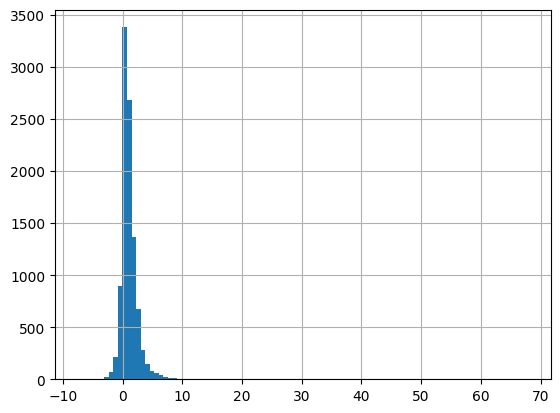

In [ ]:
df["parallax"].hist(bins=100)

### Labeled Parallax Histogram

Same plot with proper axis labels — most stars cluster at small parallax (distant), with a tail of nearby bright stars at high values:

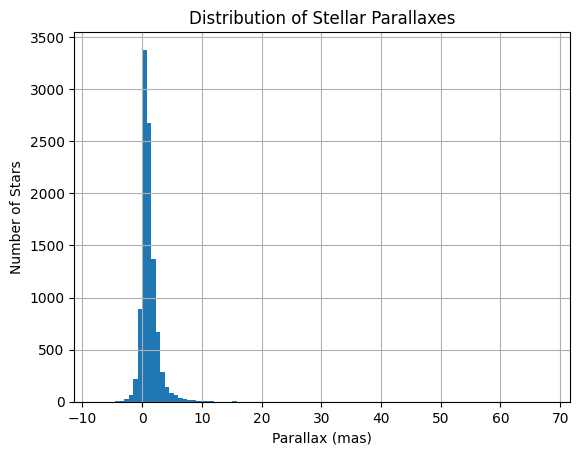

In [ ]:
import matplotlib.pyplot as plt

df["parallax"].hist(bins=100)

plt.xlabel("Parallax (mas)")

plt.ylabel("Number of Stars")

plt.title("Distribution of Stellar Parallaxes")

plt.show()

### Log-Scale Parallax Histogram

Same data on a **log y-axis** — makes rare high-parallax stars (nearby) visible alongside the dense bulk of distant stars. Without log scale, the tall distant-star bar crushes everything else.

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["parallax"], bins=100)
plt.yscale("log")
plt.xlabel("Parallax (mas)")
plt.ylabel("Number of Stars (log scale)")
plt.title("Distribution of Stellar Parallaxes")
plt.show()

## Step 4: Clean the Data

Three quality filters — each targets a specific class of bad measurement:

| Filter | Removes | Why |
|--------|---------|-----|
| `parallax > 0` | Negative parallax | Unphysical — gives negative distance |
| `parallax / parallax_error > 5` | Low signal-to-noise stars | Distance uncertainty > 25% → absolute magnitude unreliable |
| `bp_rp` not null | Stars with no color | Can't be placed on the HR diagram |

In [ ]:
import numpy as np

clean = df[
    (df["parallax"] > 0) &
    (df["parallax"] / df["parallax_error"] > 5) &
    (df["bp_rp"].notna())
].copy()

print(f"Stars before cleaning: {len(df)}")
print(f"Stars after cleaning:  {len(clean)}")
clean.head()

## Step 5: Feature Engineering

Two derived columns needed for the HR diagram — neither exists in the raw Gaia data:

**Distance in parsecs:**  
`distance_pc = 1000 / parallax_mas`  
1 parsec ≈ 3.26 light-years. Parallax in milliarcseconds inverts directly.

**Absolute magnitude:**  
`M = m − 5 × log₁₀(d / 10)`  
The **distance modulus** — strips out distance so we compare true intrinsic stellar brightness. At d = 10 pc, M = m (the standard reference point).

In [ ]:
clean["absolute_mag"] = clean["phot_g_mean_mag"] - 5 * np.log10(clean["distance_pc"] / 10)

print(clean[["bp_rp", "absolute_mag", "distance_pc"]].describe())

## Step 6: Visualize

### 6a. HR Diagram — Density Map

Hex-bin plot with log color scale reveals structure across orders of magnitude.  
**Y-axis inverted** — astronomy convention: bright (low magnitude) at top.

Look for:
- **Diagonal band** top-left → bottom-right → **main sequence**
- **Clump upper-right** (bright + red) → **red giants**
- **Sparse lower-left** (dim + blue/white) → **white dwarfs**

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.hexbin(clean["bp_rp"], clean["absolute_mag"], gridsize=50, cmap="inferno", bins="log")
plt.colorbar(label="log(count)")
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute Magnitude")
plt.title("HR Diagram — Density Map")
plt.show()

### 6a-ii. HR Diagram — Scatter Plot

Same data as the density map above but as a plain scatter plot — each dot is one star.  
Useful for spotting individual outliers and the overall population shape before density encoding hides detail.  
`s=1, alpha=0.5` keeps it readable at 10k points.

In [ ]:
plt.figure(figsize=(10, 10))
plt.scatter(
    clean["bp_rp"],
    clean["absolute_mag"],
    s=1,
    alpha=0.5
)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute Magnitude")
plt.title("Gaia HR Diagram — Scatter")
plt.show()

### 6b. Absolute Magnitude Distribution

Peak around M ≈ 4–6, dominated by main-sequence stars. Our Sun sits at M ≈ 4.83 — right in the middle.

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(clean["absolute_mag"], bins=80, color="steelblue", edgecolor="none")
plt.xlabel("Absolute Magnitude")
plt.ylabel("Number of Stars")
plt.title("Distribution of Absolute Magnitudes")
plt.show()

### 6c. Distance vs. Brightness — Malmquist Bias

At large distances only intrinsically bright stars are detectable above Gaia's flux limit. The **missing lower-right corner** (faint + far = invisible) makes this selection bias visible.

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(clean["distance_pc"], clean["absolute_mag"], s=1, alpha=0.3)
plt.gca().invert_yaxis()
plt.xlabel("Distance (pc)")
plt.ylabel("Absolute Magnitude")
plt.title("Distance vs Brightness (Malmquist Bias)")
plt.show()

---

## Summary

| Step | What we did | Key insight |
|------|-------------|-------------|
| Query | 10k stars from Gaia DR3 via ADQL | Real observational data |
| Raw explore | Naive distance → negative values | Shows exactly why cleaning is necessary |
| Clean | Removed negative parallax, low-SNR, missing color | Each filter has a physical motivation |
| Features | `distance_pc` and `absolute_mag` | Distance modulus corrects for star distance |
| Visualize | HR diagram, magnitude hist, Malmquist plot | Sample biases are visible in the data |

**Next:** [`week2_kmeans_clustering.ipynb`](week2_kmeans_clustering.ipynb) — K-Means to recover stellar populations without labels.